In [29]:
%matplotlib inline
## Load tfmodisco tiling results (mech_bins) + recompute (lfc, cossim) for the 56k.
import os, sys, json, glob, h5py, numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

CT  = {'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
CTS = ['HepG2', 'K562']
N_BINS   = 28
BIN_ROOT = os.path.join(REPO, 'genomic_targets/data/mech_bins')
BIN_DIR  = lambda ct, i: os.path.join(BIN_ROOT, ct, f'n{N_BINS}', f'bin_{i:03d}')

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{c}_log2FC' for c in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets/data/deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{c}_log2FC' for c in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n_full][keep]
    em.attr_hyp[ct]   = hyp
    em.attr[ct]       = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values

bins = {ct: [] for ct in CTS}
for ct in CTS:
    for d in sorted(glob.glob(os.path.join(BIN_ROOT, ct, f'n{N_BINS}', 'bin_*'))):
        meta = json.load(open(os.path.join(d, 'meta.json')))
        idx  = np.load(os.path.join(d, 'indices.npy'))
        with h5py.File(os.path.join(d, 'modisco.h5')) as f:
            n_pos = len(f['pos_patterns']) if 'pos_patterns' in f else 0
            n_neg = len(f['neg_patterns']) if 'neg_patterns' in f else 0
        bins[ct].append({**meta, 'dir': d, 'indices': idx, 'n_pos': n_pos, 'n_neg': n_neg})

print(f'{len(df)} seqs    n_bins={N_BINS}    bins/ct: {[len(bins[ct]) for ct in CTS]}')


EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs    n_bins=28    bins/ct: [28, 28]


In [30]:
## print summary
rows = []
for ct in CTS:
    for b in bins[ct]:
        rows.append({'ct': ct, 'bin': b['bin_idx'], 'n_seqs': b['n_seqs'],
                     'cossim_lo': b['cossim_lo'], 'cossim_hi': b['cossim_hi'],
                     'n_pos': b['n_pos'], 'n_neg': b['n_neg']})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

   ct  bin  n_seqs  cossim_lo  cossim_hi  n_pos  n_neg
HepG2    0    2035  -0.848961  -0.074290      6      0
HepG2    1    2035  -0.074267   0.062515      6      0
HepG2    2    2034   0.062536   0.149867      7      0
HepG2    3    2035   0.149946   0.212305      8      0
HepG2    4    2035   0.212359   0.267292      6      0
HepG2    5    2035   0.267318   0.313114     12      0
HepG2    6    2035   0.313137   0.352913     11      0
HepG2    7    2035   0.352960   0.389109     11      0
HepG2    8    2034   0.389116   0.423120      9      0
HepG2    9    2035   0.423168   0.454924      9      0
HepG2   10    2035   0.454930   0.485133      8      0
HepG2   11    2035   0.485141   0.513796     10      0
HepG2   12    2035   0.513800   0.540809      9      0
HepG2   13    2035   0.540826   0.567120      9      0
HepG2   14    2034   0.567121   0.591526      9      0
HepG2   15    2035   0.591557   0.615522      7      0
HepG2   16    2035   0.615530   0.640037      9      0
HepG2   17

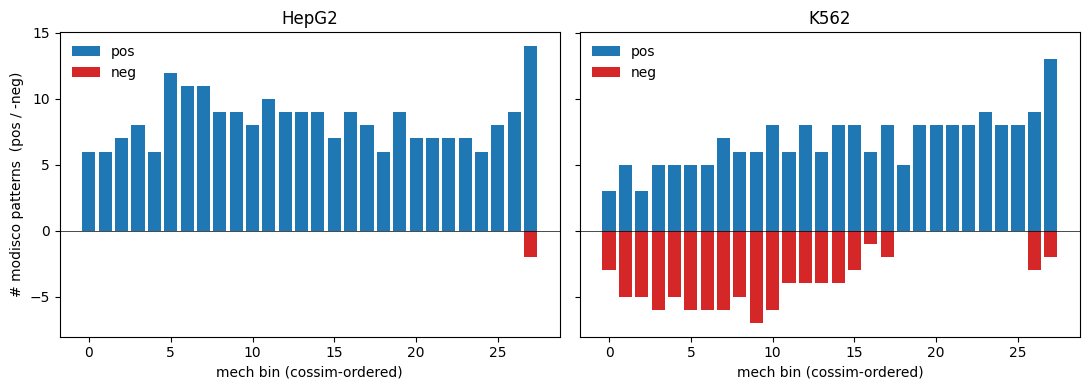

In [31]:
## visualize: # modisco patterns per bin (pos up, neg down)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, ct in zip(axes, CTS):
    xs = [b['bin_idx'] for b in bins[ct]]
    ax.bar(xs, [ b['n_pos'] for b in bins[ct]], color='#1f77b4', label='pos')
    ax.bar(xs, [-b['n_neg'] for b in bins[ct]], color='#d62728', label='neg')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('mech bin (cossim-ordered)')
    ax.set_title(ct)
    ax.legend(frameon=False)
axes[0].set_ylabel('# modisco patterns  (pos / -neg)')
plt.tight_layout(); plt.show()

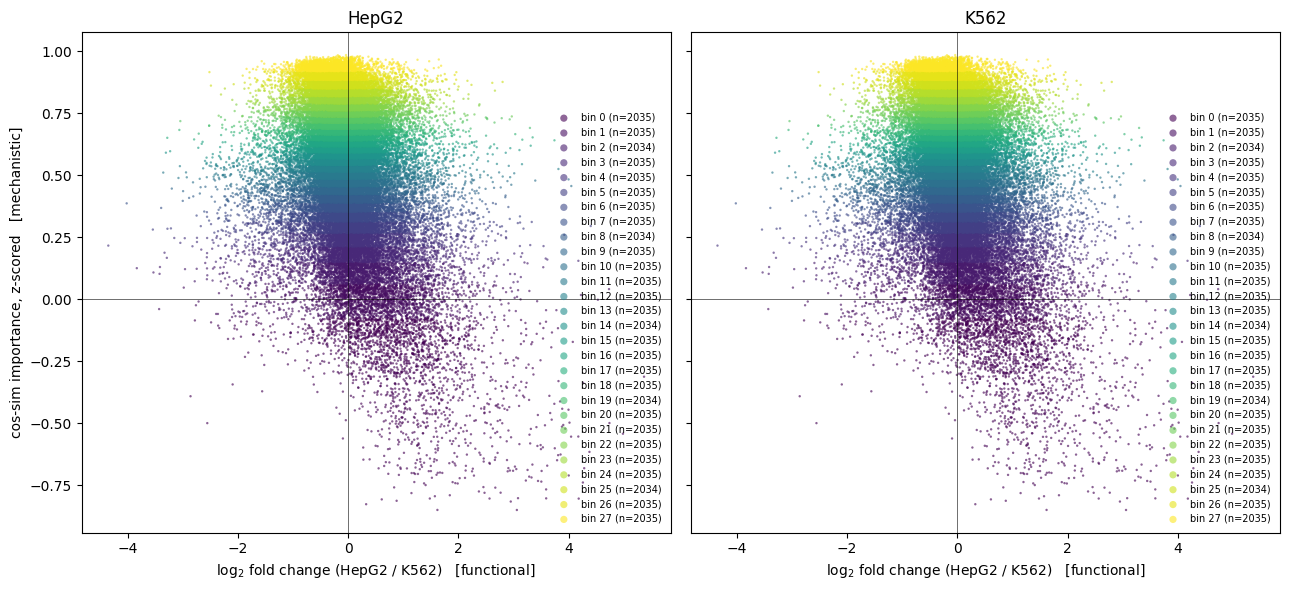

In [35]:
## show on (lfc, cossim) mech-func space; per-ct, color = bin index
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, ct in zip(axes, CTS):
    ax.scatter(lfc, cossim, s=1, c='lightgrey', alpha=0.3,
               edgecolors='none', rasterized=True)
    n_b  = len(bins[ct])
    cmap = plt.get_cmap('viridis')
    for b in bins[ct]:
        idx = b['indices']
        ax.scatter(lfc[idx], cossim[idx], s=3, alpha=0.6, edgecolors='none',
                   color=cmap(b['bin_idx'] / max(1, n_b - 1)),
                   label=f"bin {b['bin_idx']} (n={b['n_seqs']})", rasterized=True)
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax.set_title(ct)
    ax.legend(frameon=False, fontsize=7, loc='lower right', markerscale=3)
axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.tight_layout(); plt.show()

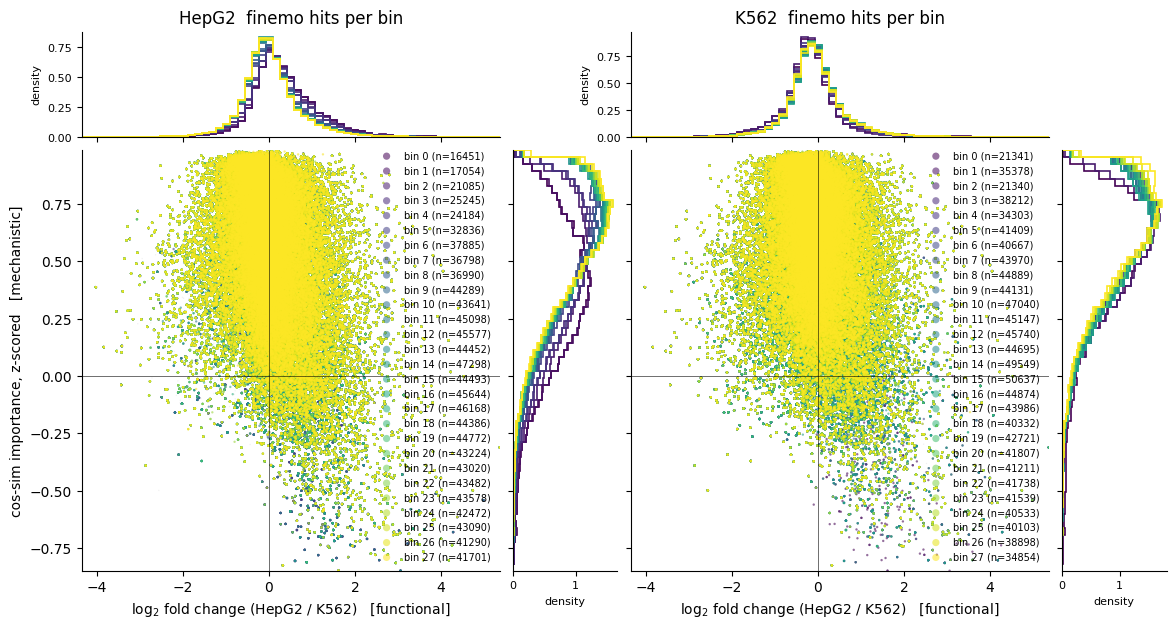

In [33]:
## finemo hits (per bin) on (lfc, cossim), per-ct, with marginal density distributions
n   = len(df)
fin = np.isfinite(lfc) & np.isfinite(cossim)
x_lim = (np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]))
y_lim = (np.nanmin(cossim[fin]), np.nanmax(cossim[fin]))
x_bins_h = np.linspace(*x_lim, 60); y_bins_h = np.linspace(*y_lim, 60)

def bin_hits_mask(b, n):
    p = os.path.join(b['dir'], 'finemo', 'hits.tsv')
    if not os.path.exists(p):
        return np.zeros(n, dtype=bool)
    ids = pd.read_csv(p, sep='\t', usecols=['peak_id'])['peak_id'].astype(int).unique()
    ids = ids[ids < n]
    m = np.zeros(n, dtype=bool); m[ids] = True
    return m

fig = plt.figure(figsize=(14, 7))
gs  = fig.add_gridspec(2, 4, width_ratios=[4, 1, 4, 1], height_ratios=[1, 4],
                       hspace=0.05, wspace=0.05)

scatter_axes = []
for col, ct in zip([0, 2], CTS):
    ax_main = fig.add_subplot(gs[1, col])
    ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
    ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

    ax_main.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
                    edgecolors='none', rasterized=True)

    n_b  = len(bins[ct])
    cmap = plt.get_cmap('viridis')
    for b in bins[ct]:
        m = bin_hits_mask(b, n) & fin
        if m.sum() < 2: continue
        c = cmap(b['bin_idx'] / max(1, n_b - 1))
        ax_main.scatter(lfc[m], cossim[m], s=3, color=c, alpha=0.55,
                        edgecolors='none', rasterized=True,
                        label=f"bin {b['bin_idx']} (n={m.sum()})")
        ax_top.hist(lfc[m],   bins=x_bins_h, color=c, density=True,
                    histtype='step', linewidth=1.2)
        ax_rt.hist(cossim[m], bins=y_bins_h, color=c, density=True,
                   histtype='step', linewidth=1.2, orientation='horizontal')

    ax_main.axhline(0, color='k', lw=0.4); ax_main.axvline(0, color='k', lw=0.4)
    ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
    ax_main.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax_main.legend(frameon=False, fontsize=7, loc='lower right', markerscale=3)
    for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

    ax_top.set_title(f'{ct}  finemo hits per bin')
    ax_top.set_ylabel('density', fontsize=8)
    ax_rt.set_xlabel('density', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_rt.get_yticklabels(),  visible=False)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_rt.tick_params(axis='x',  labelsize=8)
    for sp in ('top', 'right'):
        ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

    scatter_axes.append(ax_main)

scatter_axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.setp(scatter_axes[1].get_yticklabels(), visible=False)
plt.show()

  wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/mech_bins/HepG2/n28/bin_000/tomtom_jaspar2026.json  (6 patterns)
  wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/mech_bins/HepG2/n28/bin_027/tomtom_jaspar2026.json  (16 patterns)


  wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/mech_bins/K562/n28/bin_000/tomtom_jaspar2026.json  (6 patterns)
  wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/mech_bins/K562/n28/bin_027/tomtom_jaspar2026.json  (15 patterns)

CTCF matches in extreme bins: 4
  K562  bin 0  pos_patterns.pattern_1     MA0139.2 CTCF
  K562  bin 0  pos_patterns.pattern_2     MA1929.2 CTCF
  K562  bin 0  neg_patterns.pattern_1     MA1929.2 CTCF
  K562  bin 27  neg_patterns.pattern_1     MA1929.2 CTCF


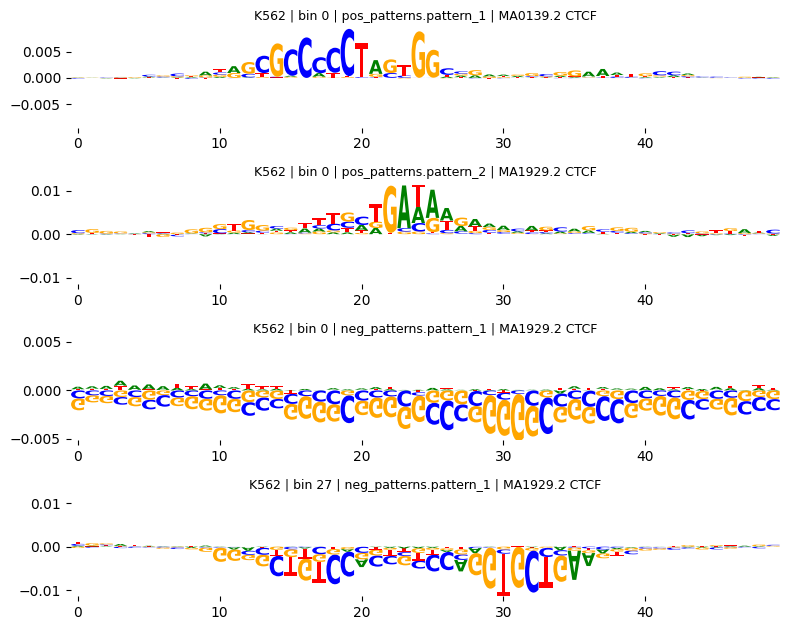

In [34]:
## Run/cache TOMTOM (JASPAR2026) per bin and plot CTCF CWMs for the cossim extremes (bin 0, bin 9).
import eigen_steering as es
es._load_heavy_deps()
fast_logo = es.fast_logo
JASPAR_MEME = es.JASPAR_MEME
from modiscolite import report as mr

EXTREMES = [0, len(bins[CTS[0]]) - 1]   # most cossim≈-1, most cossim≈+1

def ensure_tomtom(bin_dir):
    out = os.path.join(bin_dir, 'tomtom_jaspar2026.json')
    if os.path.exists(out):
        return json.load(open(out))
    h5 = os.path.join(bin_dir, 'modisco.h5')
    ann = {}
    for grp in ('pos_patterns', 'neg_patterns'):
        with h5py.File(h5) as f:
            if grp not in f: continue
        d = mr.tomtomlite_dataframe(modisco_h5py=h5, output_dir=bin_dir,
                                    meme_motif_db=JASPAR_MEME,
                                    pattern_groups=[grp], top_n_matches=1)
        if 'match0' in d:
            for k, v in d['match0'].items():
                ann[f'{grp}.pattern_{int(k)}'] = str(v)
    json.dump(ann, open(out, 'w'), indent=2, sort_keys=True)
    print(f'  wrote {out}  ({len(ann)} patterns)')
    return ann

def cwm_for(h5, key):
    grp, pat = key.split('.')
    i = int(pat.split('_')[-1])
    with h5py.File(h5) as f:
        return f[grp][f'pattern_{i}']['contrib_scores'][...]

ctcf = []   # list of (ct, bin_idx, key, ann, cwm)
for ct in CTS:
    for bi in EXTREMES:
        b   = next(x for x in bins[ct] if x['bin_idx'] == bi)
        ann = ensure_tomtom(b['dir'])
        for key, a in ann.items():
            if 'CTCF' in a.upper():
                ctcf.append((ct, bi, key, a, cwm_for(os.path.join(b['dir'], 'modisco.h5'), key)))

print(f'\nCTCF matches in extreme bins: {len(ctcf)}')
for ct, bi, key, a, _ in ctcf:
    print(f'  {ct}  bin {bi}  {key:25s}  {a}')

if ctcf:
    fig, axes = plt.subplots(len(ctcf), 1, figsize=(8, 1.6 * len(ctcf)), squeeze=False)
    for r, (ct, bi, key, a, cwm) in enumerate(ctcf):
        ax = axes[r, 0]
        yabs = max(abs(cwm).max() * 1.05, 1e-6)
        fast_logo(cwm.T, ax=ax, ylim=(-yabs, yabs))
        ax.set_title(f'{ct} | bin {bi} | {key} | {a}', fontsize=9)
        for sp in ax.spines.values(): sp.set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print('no CTCF tomtom hits in bin 0 or bin 9 for either ct')